## Bender Gestalt Test — Full Pipeline


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

DRIVE_ROOT    = '/content/drive/MyDrive/BenderTest'
IMAGES_DIR    = os.path.join(DRIVE_ROOT, 'images')
TEMPLATES_DIR = os.path.join(DRIVE_ROOT, 'templates')
EXCEL_PATH    = os.path.join(DRIVE_ROOT, 'bender_gestalt_reveiws.xlsx')
OUTPUT_DIR    = os.path.join(DRIVE_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Imports

In [3]:
import glob, re
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter
import torch

# PART 1 — COMPUTER VISION PIPELINE


## Load images & quick visual check_

Found 89 student images
Portrait (tall) : 89   |   Landscape (wide) : 0
Both orientations handled — NO rotation applied.


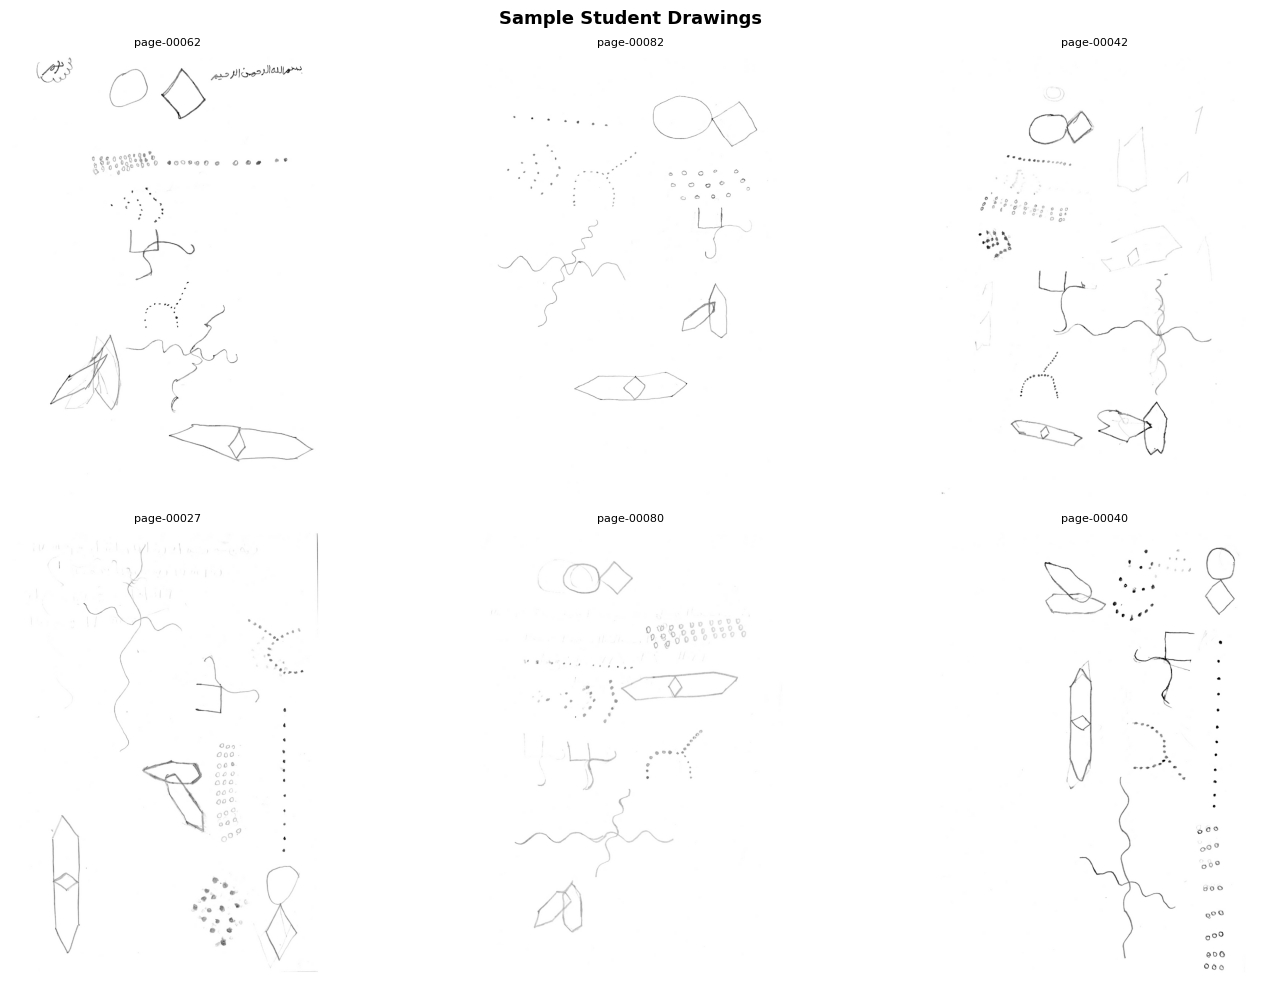

In [4]:
image_paths = glob.glob(os.path.join(IMAGES_DIR, '*.jpg'))
print(f'Found {len(image_paths)} student images')

# Orientation counts (portrait vs landscape) — DO NOT rotate
portrait = landscape = 0
valid_image_paths = []
for p in image_paths:
    try:
        w, h = Image.open(p).size
        if h >= w: portrait  += 1
        else:      landscape += 1
        valid_image_paths.append(p)
    except OSError as e:
        print(f"Could not open {Path(p).name}: {e}")
        continue

image_paths = valid_image_paths # Update image_paths to only include valid ones

print(f'Portrait (tall) : {portrait}   |   Landscape (wide) : {landscape}')
print('Both orientations handled — NO rotation applied.')

# Show 6 random samples
import random
if len(image_paths) > 0:
    sample = random.sample(image_paths, min(6, len(image_paths)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, p in zip(axes.flatten(), sample):
        ax.imshow(Image.open(p), cmap='gray')
        ax.set_title(Path(p).stem, fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Student Drawings', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_drawings.png'), dpi=150)
    plt.show()
else:
    print('No valid images to display samples.')

## CV helper functions (template match + feature extraction)

In [5]:
from skimage.metrics import structural_similarity as ssim

# 1. Multi-scale template matching
#    Tries 20 scales so it finds figures regardless of how large the
#    student drew them relative to the reference template.

def multi_scale_match(img_gray, tmpl_gray, n_scales=20):
    scales     = np.linspace(0.3, 2.0, n_scales)
    best_score = -1.0
    best_bbox  = (0, 0, 1, 1)
    best_scale = 1.0
    th, tw     = tmpl_gray.shape
    ih, iw     = img_gray.shape

    for s in scales:
        nw, nh = int(tw * s), int(th * s)
        if nw < 8 or nh < 8 or nw > iw or nh > ih:
            continue
        resized = cv2.resize(tmpl_gray, (nw, nh))
        res     = cv2.matchTemplate(img_gray, resized, cv2.TM_CCOEFF_NORMED)
        _, val, _, loc = cv2.minMaxLoc(res)
        if val > best_score:
            best_score = val
            best_bbox  = (loc[0], loc[1], nw, nh)
            best_scale = s

    return best_score, best_bbox, best_scale


# 2. Erasure detection
#    Erasures leave many tiny connected components (smudge residue).
#    We count small blobs relative to crop area as the erasure score.

def detect_erasure(crop_gray, threshold=0.15):
    blur      = cv2.GaussianBlur(crop_gray, (5, 5), 0)
    _, bw     = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY_INV)
    n, _, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    if n <= 1:
        return 0, 0.0
    areas         = stats[1:, cv2.CC_STAT_AREA]
    small_blobs   = int(np.sum(areas < 50))
    total_area    = crop_gray.shape[0] * crop_gray.shape[1] + 1e-9
    erasure_score = small_blobs / (total_area / 100)
    return int(erasure_score > threshold), round(float(erasure_score), 4)


# 3. Rotation estimation with Hough lines (Segment the shapes that have lines)

def estimate_rotation(crop_gray):
    edges = cv2.Canny(crop_gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 30,
                             minLineLength=15, maxLineGap=8)
    if lines is None:
        return 0.0
    angles = [np.degrees(np.arctan2(y2-y1, x2-x1))
              for x1,y1,x2,y2 in lines[:,0] if x2-x1 != 0]
    return round(float(np.median(angles)), 2) if angles else 0.0


# 4. Distortion via SSIM (1 – similarity)
#    Higher = more distorted compared to the reference template.
def compute_distortion(crop_gray, tmpl_gray):
    size = (128, 128)
    a = cv2.resize(crop_gray, size)
    b = cv2.resize(tmpl_gray, size)
    score = ssim(a, b, data_range=255)
    return round(1.0 - float(score), 4)


# 5. Closure difficulty — checks if figure boundary is open/broken

def closure_difficulty(crop_gray):
    _, bw   = cv2.threshold(crop_gray, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    # More fragmented contours = more closure difficulty
    total_area = crop_gray.shape[0] * crop_gray.shape[1]
    score = len(contours) / (total_area / 500 + 1e-9)
    return round(min(float(score), 1.0), 4)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## IP pipeline on all 89 student images

In [7]:
tmpl_paths = glob.glob(os.path.join(TEMPLATES_DIR, '*.jpg'))
templates = []
for i, p in enumerate(tmpl_paths):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        templates.append({'figure': i+1, 'img': img, 'path': p})
print(f'Loaded {len(templates)} / 9 templates')

MATCH_THRESH = 0.25   # minimum confidence to call a figure "detected"

cv_records = []

for img_path in tqdm(image_paths, desc='CV Processing'):
    student_id = Path(img_path).stem
    img_bgr    = cv2.imread(img_path)
    if img_bgr is None:
        print(f' Could not read {img_path}')
        continue

    # DO NOT rotate — keep original orientation
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # CLAHE contrast enhancement (helps with faint pencil marks)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_gray = clahe.apply(img_gray)

    row = {'student_id': student_id}

    for tmpl in templates:
        fig = tmpl['figure']
        score, bbox, scale = multi_scale_match(img_gray, tmpl['img'])
        detected = int(score >= MATCH_THRESH)

        row[f'fig{fig}_detected']   = detected
        row[f'fig{fig}_confidence'] = round(score, 4)

        if detected:
            x, y, w, h = bbox
            x1 = max(0, x);  y1 = max(0, y)
            x2 = min(img_gray.shape[1], x+w)
            y2 = min(img_gray.shape[0], y+h)
            crop = img_gray[y1:y2, x1:x2]

            if crop.size == 0:
                crop = img_gray  # fallback

            has_erasure, erasure_scr = detect_erasure(crop)
            rotation                 = estimate_rotation(crop)
            distortion               = compute_distortion(crop, tmpl['img'])
            closure                  = closure_difficulty(crop)

            row[f'fig{fig}_erasure']     = has_erasure
            row[f'fig{fig}_erasure_scr'] = erasure_scr
            row[f'fig{fig}_rotation']    = rotation
            row[f'fig{fig}_distortion']  = distortion
            row[f'fig{fig}_closure']     = closure
            row[f'fig{fig}_pos_x']       = round(x / img_gray.shape[1], 4)
            row[f'fig{fig}_pos_y']       = round(y / img_gray.shape[0], 4)
            row[f'fig{fig}_scale']       = round(scale, 4)
        else:
            # Fill sentinel values for undetected figure
            for suffix, val in [('erasure',0),('erasure_scr',0.0),
                                  ('rotation',0.0),('distortion',1.0),
                                  ('closure',0.0),('pos_x',-1.0),
                                  ('pos_y',-1.0),('scale',0.0)]:
                row[f'fig{fig}_{suffix}'] = val

    cv_records.append(row)

df_cv = pd.DataFrame(cv_records)
print(f'\nCV Pipeline. Shape: {df_cv.shape}')

# Global summary features across all 9 figures
detection_cols = [f'fig{i}_detected'   for i in range(1,10)]
erasure_cols   = [f'fig{i}_erasure'    for i in range(1,10)]
distort_cols   = [f'fig{i}_distortion' for i in range(1,10)]
rotation_cols  = [f'fig{i}_rotation'   for i in range(1,10)]

df_cv['total_detected']       = df_cv[detection_cols].sum(axis=1)
df_cv['total_erasures']       = df_cv[erasure_cols].sum(axis=1)
df_cv['mean_distortion']      = df_cv[distort_cols].mean(axis=1).round(4)
df_cv['mean_abs_rotation']    = df_cv[rotation_cols].abs().mean(axis=1).round(4)
df_cv['max_distortion']       = df_cv[distort_cols].max(axis=1).round(4)
df_cv['any_erasure']          = (df_cv['total_erasures'] > 0).astype(int)

print(f'Final CV feature matrix shape: {df_cv.shape}')
df_cv.head(3)

Loaded 9 / 9 templates


CV Processing:   0%|          | 0/89 [00:00<?, ?it/s]


CV Pipeline. Shape: (89, 91)
Final CV feature matrix shape: (89, 97)


,student_id,fig1_detected,fig1_confidence,fig1_erasure,fig1_erasure_scr,fig1_rotation,fig1_distortion,fig1_closure,fig1_pos_x,fig1_pos_y,...,fig9_closure,fig9_pos_x,fig9_pos_y,fig9_scale,total_detected,total_erasures,mean_distortion,mean_abs_rotation,max_distortion,any_erasure
0,page-0011,0,0.0958,0,0.0,0.0,1.0,0.0,-1.0,-1.0,...,0.0,-1.0,-1.0,0.0,0,0,1.0000,0.0000,1.0,0
1,page-00052,0,0.1417,0,0.0,0.0,1.0,0.0,-1.0,-1.0,...,0.0,-1.0,-1.0,0.0,2,0,0.8173,6.6133,1.0,0
2,page-0024,0,0.0998,0,0.0,0.0,1.0,0.0,-1.0,-1.0,...,0.0,-1.0,-1.0,0.0,0,0,1.0000,0.0000,1.0,0
